# Adapter Evaluation

Generate lyrics from trained adapters, classify with RoBERTa, and compare against baselines.

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from transformers import AutoModelForSequenceClassification, AutoTokenizer as AT
from peft import PeftModel

model_path = "./models/gemma-4-E4B"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    model_path,
    quantization_config=bnb_config,
    device_map="auto",
)
tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer.pad_token = tokenizer.eos_token

clf_path = "./classifier_output/best_model"
clf_model = AutoModelForSequenceClassification.from_pretrained(clf_path)
clf_tokenizer = AT.from_pretrained(clf_path)
clf_model.eval()
labels = clf_model.config.id2label

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

/home/aliozkaya/uni/467/term_project/src/.venv/lib/python3.14/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [2]:
def generate_lyrics(model, prompt="Write song lyrics.\n\n", max_new_tokens=512, min_new_tokens=200):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[1]
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        min_new_tokens=min_new_tokens,
        temperature=0.9,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.1,
    )
    return tokenizer.decode(outputs[0][prompt_len:], skip_special_tokens=True)


def classify(text):
    enc = clf_tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        logits = clf_model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[0]
    return {labels[j]: probs[j].item() for j in range(len(labels))}


def evaluate_adapter(adapter_path, n_samples=10):
    model = PeftModel.from_pretrained(base_model, adapter_path)
    results = []
    samples = []
    for i in range(n_samples):
        text = generate_lyrics(model)
        samples.append(text)
        probs = classify(text)
        results.append(probs)
        top = max(probs, key=probs.get)
        print(f"  Sample {i+1}: {top} ({probs[top]:.3f})")
    model.unload()
    return samples, pd.DataFrame(results)

## Adapter results

In [3]:
adapters = {
    "Gojira LoRA r=8":  ("Gojira", "./adapters/gojira_lora_r8"),
    "Gojira DoRA r=8":  ("Gojira", "./adapters/gojira_dora_r8"),
    "Gojira LoRA r=4":  ("Gojira", "./adapters/gojira_lora_r4"),
    "Gojira LoRA r=16": ("Gojira", "./adapters/gojira_lora_r16"),
    "Tool LoRA r=8":    ("Tool",   "./adapters/tool_lora_r8"),
    "Tool DoRA r=8":    ("Tool",   "./adapters/tool_dora_r8"),
}

all_results = {}

for name, (target, path) in adapters.items():
    print(f"\n=== {name} ===")
    samples, df = evaluate_adapter(path)
    all_results[name] = {"target": target, "samples": samples, "df": df}
    print(f"  Target-artist mean: {df[target].mean():.4f} +/- {df[target].std():.4f}")


=== Gojira LoRA r=8 ===


/home/aliozkaya/uni/467/term_project/src/.venv/lib/python3.14/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  Sample 1: Gojira (0.968)
  Sample 2: Gojira (0.990)
  Sample 3: Gojira (0.987)
  Sample 4: Gojira (0.987)
  Sample 5: Gojira (0.986)
  Sample 6: Gojira (0.988)
  Sample 7: Gojira (0.990)
  Sample 8: Gojira (0.991)
  Sample 9: Gojira (0.966)
  Sample 10: Gojira (0.974)
  Target-artist mean: 0.9829 +/- 0.0097

=== Gojira DoRA r=8 ===


/home/aliozkaya/uni/467/term_project/src/.venv/lib/python3.14/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  Sample 1: Gojira (0.990)
  Sample 2: Gojira (0.991)
  Sample 3: Gojira (0.988)
  Sample 4: Gojira (0.989)
  Sample 5: Gojira (0.986)
  Sample 6: Gojira (0.991)
  Sample 7: Gojira (0.990)
  Sample 8: Gojira (0.989)
  Sample 9: Gojira (0.989)
  Sample 10: Gojira (0.986)
  Target-artist mean: 0.9889 +/- 0.0019

=== Gojira LoRA r=4 ===


...

  Sample 1: Gojira (0.991)
  Sample 2: Gojira (0.990)
  Sample 3: Gojira (0.989)
  Sample 4: Gojira (0.657)
  Sample 5: Gojira (0.979)
  Sample 6: Gojira (0.988)
  Sample 7: Gojira (0.991)
  Sample 8: Gojira (0.991)
  Sample 9: Gojira (0.991)
  Sample 10: Gojira (0.991)
  Target-artist mean: 0.9558 +/- 0.1050

=== Tool LoRA r=8 ===


/home/aliozkaya/uni/467/term_project/src/.venv/lib/python3.14/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  Sample 1: Tool (0.990)
  Sample 2: Tool (0.992)
  Sample 3: Tool (0.752)
  Sample 4: Tool (0.601)
  Sample 5: Tool (0.983)
  Sample 6: Tool (0.757)
  Sample 7: Tool (0.992)
  Sample 8: Tool (0.993)
  Sample 9: Tool (0.580)
  Sample 10: Tool (0.992)
  Target-artist mean: 0.8631 +/- 0.1731

=== Tool DoRA r=8 ===


/home/aliozkaya/uni/467/term_project/src/.venv/lib/python3.14/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  Sample 1: Tool (0.985)
  Sample 2: Tool (0.979)
  Sample 3: Tool (0.885)
  Sample 4: Tool (0.992)
  Sample 5: Tool (0.876)
  Sample 6: Tool (0.971)
  Sample 7: Tool (0.733)
  Sample 8: Gojira (0.658)
  Sample 9: Tool (0.992)
  Sample 10: Opeth (0.979)
  Target-artist mean: 0.7721 +/- 0.3430


## Baselines (from 04_baselines.ipynb)

Hardcoded baseline results to enable unified comparison.

In [4]:
baselines = {
    "Gojira Zero-shot": {"target": "Gojira", "mean": 0.0105, "std": 0.0075},
    "Gojira Few-shot":  {"target": "Gojira", "mean": 0.0830, "std": 0.2345},
    "Tool Zero-shot":   {"target": "Tool",   "mean": 0.9711, "std": 0.0343},
    "Tool Few-shot":    {"target": "Tool",   "mean": 0.9471, "std": 0.0441},
}

rows = []

for name, b in baselines.items():
    rows.append({
        "Method": name,
        "Artist": b["target"],
        "Target Attr. (mean)": b["mean"],
        "Target Attr. (std)": b["std"],
    })

for name, data in all_results.items():
    target = data["target"]
    rows.append({
        "Method": name,
        "Artist": target,
        "Target Attr. (mean)": data["df"][target].mean(),
        "Target Attr. (std)": data["df"][target].std(),
    })

summary = pd.DataFrame(rows)
summary["Target Attr. (mean)"] = summary["Target Attr. (mean)"].round(4)
summary["Target Attr. (std)"] = summary["Target Attr. (std)"].round(4)
print(summary.to_string(index=False))

          Method Artist  Target Attr. (mean)  Target Attr. (std)
Gojira Zero-shot Gojira               0.0105              0.0075
 Gojira Few-shot Gojira               0.0830              0.2345
  Tool Zero-shot   Tool               0.9711              0.0343
   Tool Few-shot   Tool               0.9471              0.0441
 Gojira LoRA r=8 Gojira               0.9829              0.0097
 Gojira DoRA r=8 Gojira               0.9889              0.0019
 Gojira LoRA r=4 Gojira               0.8812              0.2751
Gojira LoRA r=16 Gojira               0.9558              0.1050
   Tool LoRA r=8   Tool               0.8631              0.1731
   Tool DoRA r=8   Tool               0.7721              0.3430


## Plots

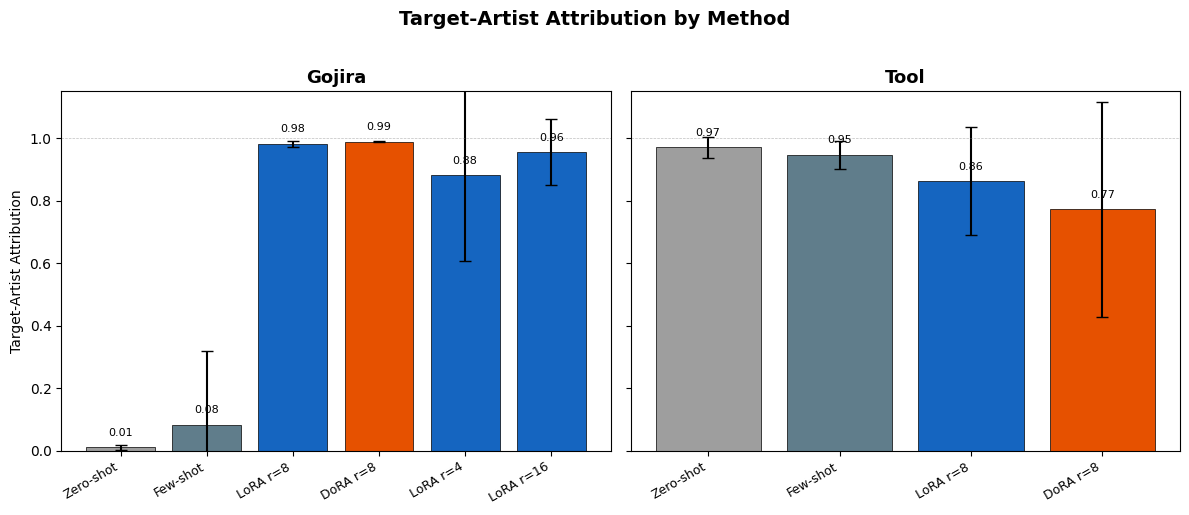

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, artist in zip(axes, ["Gojira", "Tool"]):
    artist_rows = summary[summary["Artist"] == artist].copy()
    artist_rows["short"] = artist_rows["Method"].str.replace(f"{artist} ", "")
    means = artist_rows["Target Attr. (mean)"].values
    stds = artist_rows["Target Attr. (std)"].values
    labels_plot = artist_rows["short"].values
    x = np.arange(len(labels_plot))

    colors = []
    for label in labels_plot:
        if "Zero" in label:
            colors.append("#9e9e9e")
        elif "Few" in label:
            colors.append("#607d8b")
        elif "DoRA" in label:
            colors.append("#e65100")
        else:
            colors.append("#1565c0")

    bars = ax.bar(x, means, yerr=stds, capsize=4, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_plot, rotation=30, ha="right", fontsize=9)
    ax.set_title(f"{artist}", fontsize=13, fontweight="bold")
    ax.set_ylabel("Target-Artist Attribution" if artist == "Gojira" else "")
    ax.set_ylim(0, 1.15)
    ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                f"{m:.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Target-Artist Attribution by Method", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../report/figures/method_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

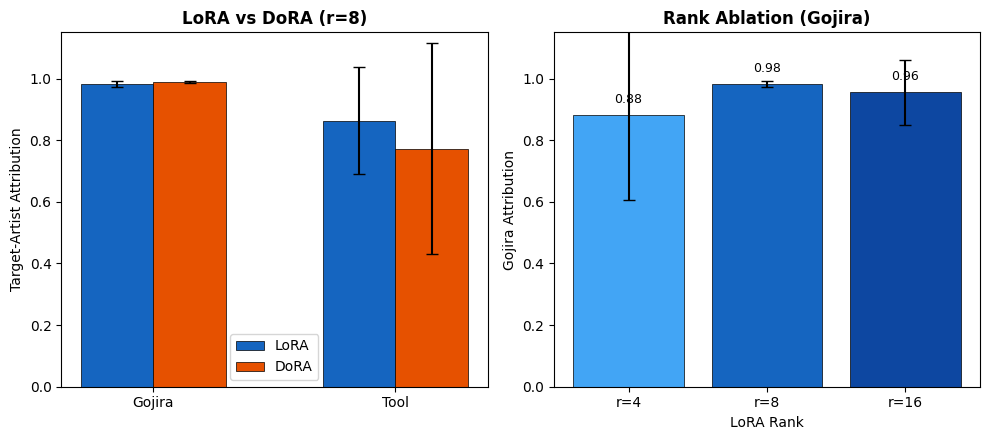

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# LoRA vs DoRA ablation
ablation_lora_dora = {
    "Gojira": ("Gojira LoRA r=8", "Gojira DoRA r=8"),
    "Tool": ("Tool LoRA r=8", "Tool DoRA r=8"),
}

ax = axes[0]
x = np.arange(len(ablation_lora_dora))
w = 0.3
for i, (method, color) in enumerate([("LoRA", "#1565c0"), ("DoRA", "#e65100")]):
    means, stds = [], []
    for artist, (lora_key, dora_key) in ablation_lora_dora.items():
        key = lora_key if method == "LoRA" else dora_key
        target = all_results[key]["target"]
        means.append(all_results[key]["df"][target].mean())
        stds.append(all_results[key]["df"][target].std())
    ax.bar(x + i * w, means, w, yerr=stds, capsize=4, label=method,
           color=color, edgecolor="black", linewidth=0.5)
ax.set_xticks(x + w / 2)
ax.set_xticklabels(list(ablation_lora_dora.keys()))
ax.set_ylabel("Target-Artist Attribution")
ax.set_title("LoRA vs DoRA (r=8)", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.15)

# Rank ablation (Gojira only)
ax = axes[1]
rank_keys = ["Gojira LoRA r=4", "Gojira LoRA r=8", "Gojira LoRA r=16"]
rank_labels = ["r=4", "r=8", "r=16"]
rank_means = [all_results[k]["df"]["Gojira"].mean() for k in rank_keys]
rank_stds = [all_results[k]["df"]["Gojira"].std() for k in rank_keys]
bars = ax.bar(rank_labels, rank_means, yerr=rank_stds, capsize=4,
              color=["#42a5f5", "#1565c0", "#0d47a1"], edgecolor="black", linewidth=0.5)
for bar, m in zip(bars, rank_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f"{m:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Gojira Attribution")
ax.set_xlabel("LoRA Rank")
ax.set_title("Rank Ablation (Gojira)", fontweight="bold")
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig("../report/figures/ablation.pdf", bbox_inches="tight", dpi=300)
plt.show()

## Sample Lyrics

Best sample per adapter (highest target-artist attribution).

In [7]:
for name, data in all_results.items():
    target = data["target"]
    best_idx = data["df"][target].idxmax()
    score = data["df"].loc[best_idx, target]
    text = data["samples"][best_idx]
    print(f"{'='*60}")
    print(f"{name} — best sample (attribution: {score:.3f})")
    print(f"{'='*60}")
    print(text[:800])
    print("...\n" if len(text) > 800 else "\n")

Gojira LoRA r=8 — best sample (attribution: 0.991)
I don't remember when I started to doubt myself
The answers are coming from my mind, all around me
It's no use complaining 'bout the way I have been ruled
My own freedom is in the hands of none but me
I used to be so proud and pretentious
But now I see through everything
There has always been a reason for what we do
That's the only truth that matters


On my side stands my secret weapon
All around lies fear and confusion
And as I grow older I start to understand
This world ain't real at all


Now I find shelter under my wings, I rest on my arms
Surrender to this great power inside, let it flow through me
I open myself wide to this world, awake my soul
Open your eyes now
It comes to life, I hear the roar
Of giants living deep inside of us
With every step you take, you learn something new
Ab
...

Gojira DoRA r=8 — best sample (attribution: 0.991)
For those of you that think we're all alone
We are not, our soul is awake
We take back what 